# Q11 - Clustering

Clustering is a form of unsupervised machine learning, with a discrete output. The learning is unsupervised as our data do not have any labels beforehand, that we can use for testing. Instead we just have some data, that we would like to order into groups. Don't know which groups or how many groups there are. 

A good use case for this is for example recommendations of restaurants or movies. Clustering is good at finding patterns, such that we might know if you like this type of food, you would like this restaurant. 

### Focus a: K-means and mean-shift
Different algorithms for clustering. In this exercise, we have badminton poses, constructed by 2d points of skeletal joints. 

K-means algorithm does clustering by randomly choosing k different cluster centroids in the data, and then assigning all other points to their closest centroids (distance metric). With these initial clusters, now choose the mean point of each cluster and repeat until cluster doesn't change. The entire process is repeated multiple times, and the method chooses the clusters with the most even variances. You need to know K value before beginning, know your data. Works best for even shaped clusters, elongated shapes are split. Outliers can break the clusters. 
After fitting model, you have the cluster centroids that are good representatives of the clusters. 

Mean-shift is another method. Don't need to know amount of clusters beforehand. Works by having 
each points have a mean shift vector, that points in the direction of density or mass (high density of other points). Points will move towards high density locations and become part of that cluster. Points have a bandwidth (distance metric) of how far they can look, so it prioritises density close to itself. Good as we don't need k, and also works for uneven shaped clusters compared to k-means. But have to select bandwidth parameter. Large bandwidth, less clusters. 

### Focus b: K-means and agglomerative
Different algorithms for clustering. In this exercise, we have badminton poses, constructed by 2d points of skeletal joints. 

K-means algorithm does clustering by randomly choosing k different cluster centroids in the data, and then assigning all other points to their closest centroids (distance metric). With these initial clusters, now choose the mean point of each cluster and repeat until cluster doesn't change. The entire process is repeated multiple times, and the method chooses the clusters with the most even variances. You need to know K value before beginning, know your data. Works best for even shaped clusters, elongated shapes are split. Outliers can break the clusters. 
After fitting model, you have the cluster centroids that are good representatives of the clusters.

Agglomerative uses cluster hierarchy, and the algortihm is pretty simple. Visualise with dendrogram. Each point is a cluster, merge clusters that are closest. Repeat until everything is one cluster. Dendogram shows the distance between clusters. Don't need any parameters to start, but need to decide what distance threshold to set. One method is finding largest vertical distance with no cluster overlap. Or can use a threshold (know your data)

### Focus c: K-means and elbow
Different algorithms for clustering. In this exercise, we have badminton poses, constructed by 2d points of skeletal joints. 

K-means algorithm does clustering by randomly choosing k different cluster centroids in the data, and then assigning all other points to their closest centroids (distance metric). With these initial clusters, now choose the mean point of each cluster and repeat until cluster doesn't change. The entire process is repeated multiple times, and the method chooses the clusters with the most even variances. You need to know K value before beginning, know your data. Works best for even shaped clusters, elongated shapes are split. Outliers can break the clusters. 
After fitting model, you have the cluster centroids that are good representatives of the clusters.

How do we choose k? Elbow method helps. 
Iteratively fit model with interval of k
within cluster sum of squares, goal is low. after k=8, wcss flattens
rate of change, stop when it becomes low. also k=8


# Clustering
This exercise is about clustering (_K-means clustering_, _Mean-shift clustering_, and _Agglomerative_) pose data used for the exercises in week 2
 and week 10
. The task includes applying and experimenting with each method and then comparing their outcomes. The comparison will be conducted by clustering a sequence of human poses using these three methods in similar steps.
The dataset tensor contains 1403 pose sequences. Each sequence is a 100-frames time series capturing human poses. Each pose consists of 25 skeletal joints, where each joint is defined by an x and y coordinate ($25 \cdot 2$). The shape of the dataset tensor is $(1403, 100, 25 \cdot 2)$. For this exercise, you will use a single pose sequence of 100 frames and apply clustering to the sequence.
## Task overview
For each clustering method you will:
- Implement the method.
- Plot the clusters in the sequence.
- Plot the cluster centers.


<article class="message">
    <div class="message-body">
        <strong>List of individual tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#loading00">Task 1: Introduction</a>
            </li>
            <li>
            <a href="#loading_files">Task 2: Setting up the data</a>
            </li>
            <li>
            <a href="#loading">Task 3: Fitting the algorithm</a>
            </li>
            <li>
            <a href="#loading2">Task 4: K-means clustering visualization</a>
            </li>
            <li>
            <a href="#loading02">Task 5: Cluster characteristics 1</a>
            </li>
            <li>
            <a href="#loading022">Task 6: Cluster centers</a>
            </li>
            <li>
            <a href="#loading023">Task 7: Cluster centers</a>
            </li>
            <li>
            <a href="#loading3">Task 8: Elbow Method</a>
            </li>
            <li>
            <a href="#loading4">Task 9: Fitting the mean-shift algorithm</a>
            </li>
            <li>
            <a href="#loading5">Task 10: Visualizing clusters</a>
            </li>
            <li>
            <a href="#loading9">Task 11: Reflection and the bandwith parameter</a>
            </li>
            <li>
            <a href="#loading10">Task 12: Dendrograms</a>
            </li>
            <li>
            <a href="#loading123">Task 13: Dendogram</a>
            </li>
            <li>
            <a href="#loading11">Task 14: Fitting the agglomerative clustering alg…</a>
            </li>
            <li>
            <a href="#loading12">Task 15: Agglomerative clustreing algorithm mean …</a>
            </li>
            <li>
            <a href="#loading122">Task 16: Agglomerative clustreing algorithm mean …</a>
            </li>
            <li>
            <a href="#loading13">Task 17: Compare and reflect on the methods</a>
            </li>
        </ul>
    </div>
</article>


---
**Task 1 (easy): Introduction💡**
1. Which information can be obtained by clustering a sequence of pose data. Include distance metrics and window size in your discussion.
2. Identify possible pitfalls.


---

In [0]:
# Write reflections here...
# 1. clustering poses, 

The following cells import libraries and provide functions for plotting the poses:


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
from sklearn.cluster import MeanShift
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import pdist, squareform
import scipy.cluster.hierarchy as shc
from scipy.cluster.hierarchy import dendrogram, linkage
from clustering_utils import *


# Suppress the specific warning
warnings.filterwarnings("ignore")


---
**Task 2 (easy): Setting up the data👩‍💻**
1. Run the cell below to load and reshape the dataset.
2. Choose the 100th pose sequence as the dataset.


---

In [2]:
data = np.load('poses_norm.npy')
N,T,D,C = data.shape
reshaped_data = data.reshape(N,T,D*C)
sequence = reshaped_data[99]
print(sequence.shape)

(100, 50)


## K-means Clustering
In this  exercise you will use k-means clustering on a pose sequence. 

---
**Task 3 (easy): Fitting the algorithm👩‍💻**
1. Run the cell below to create an instance of the `KMeans`
 class with 7 clusters and to find clusters in the sequence.


---

In [21]:
# Specify the number of clusters (k)
k = 5

# Create KMeans 
kmeans = KMeans(n_clusters=k, random_state=0)

# Fit to the data
kmeans.fit(sequence)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'



---
**Task 4 (easy): K-means clustering visualization👩‍💻**
1. Use the [documentation on the `labels_`
 attribute.](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
 to obtain cluster labels. 
2. Use the `plot_single_pose`
 function from the file `clustering _utils.py`
 to color each pose in the pose sequence according to which cluster it belongs to. 


---

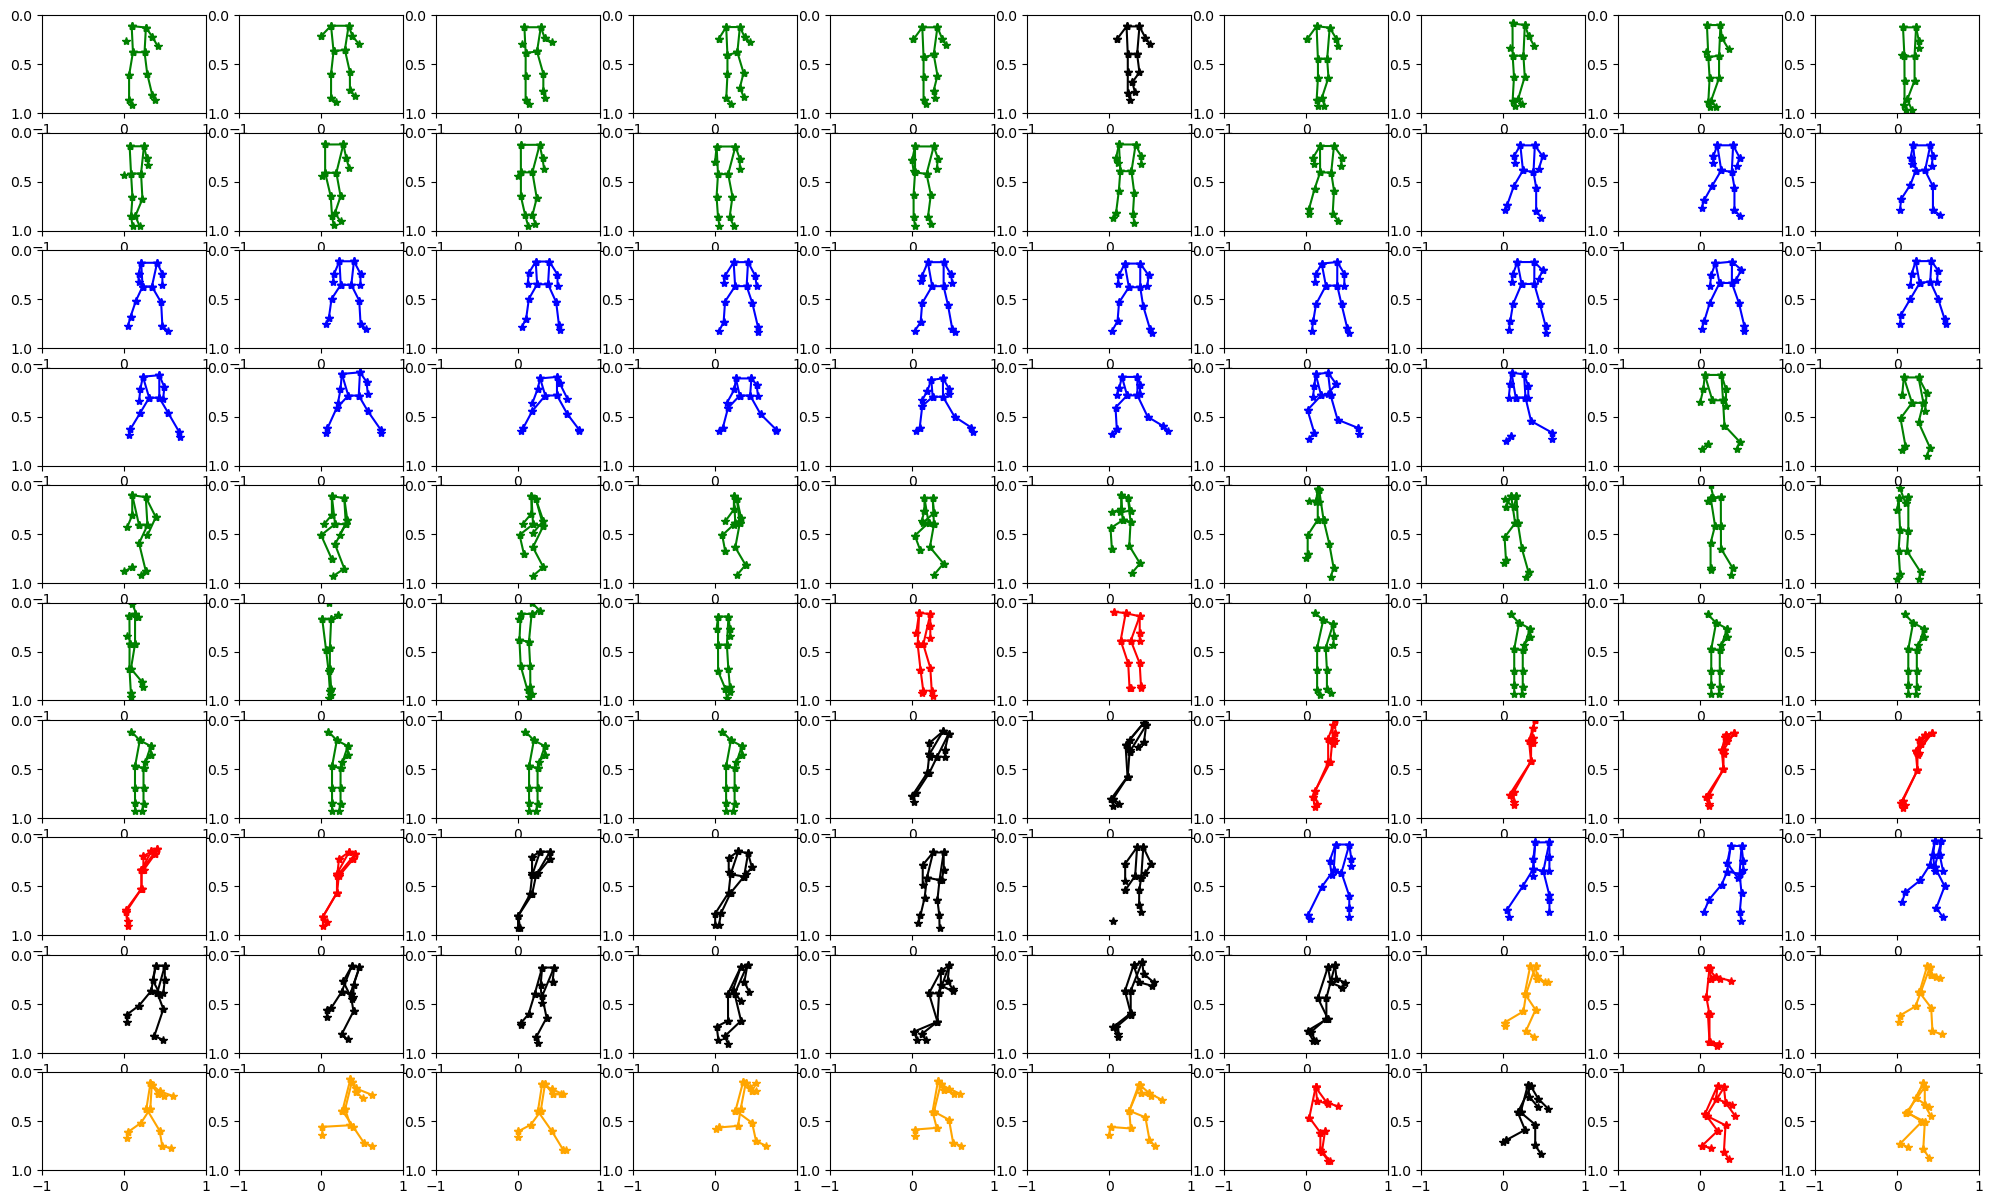

In [23]:
# Write your solution here
cluster_labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# You can now use 'cluster_labels' to see which cluster each frame belongs to
# 'centroids' contains the coordinates of the cluster centers

colors = {0: 'red', 1: 'blue', 2: 'green', 3: "orange", 4: "black", 5: "brown", 6: "yellow", 7: "cyan", 8:""}  # Map cluster labels to colors
plt.figure(figsize=(25,15))
for i in range(len(sequence)):
    plt.subplot(10, 10, i + 1)
    plot_single_pose(sequence[i], c=colors[cluster_labels[i]], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)


---
**Task 5 (easy): Cluster characteristics 1💡**
1. What characterizes the _blue_, _green_ and _red_ poses?


---

In [0]:
# Write your reflections here...
# blue = spread legs, facing right, hands are lifted together holding bat
# green = most common cluster, front facing pose with legs relatively close together. High variance.
# red = stepping to the left


---
**Task 6 (easy): Cluster centers👩‍💻**
1. Run the cell below to extract and plot the cluster centers.


---

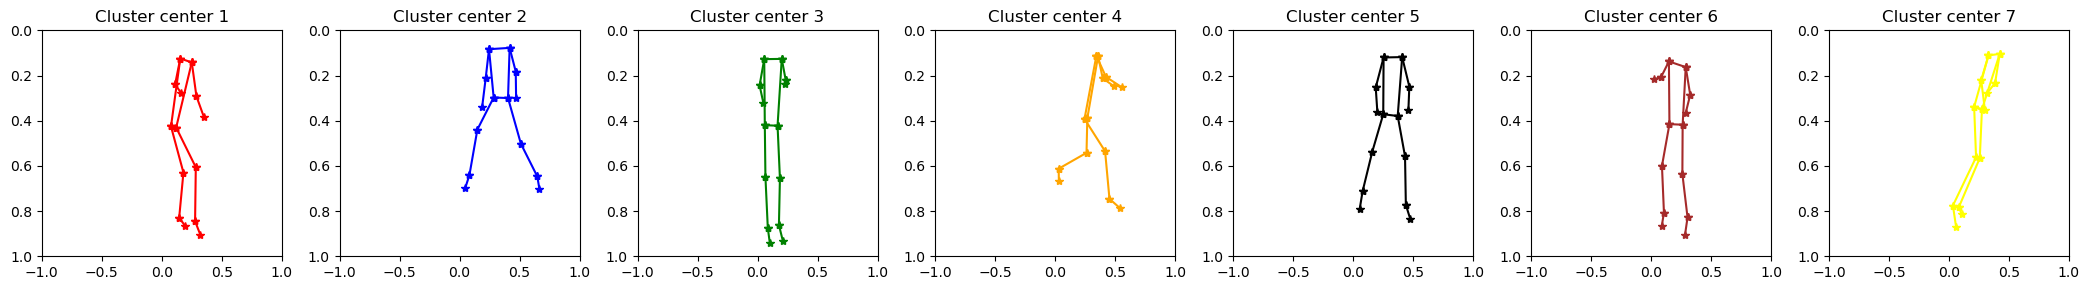

In [14]:
num_centroids = len(centroids)
# Set up subplots
fig, axes = plt.subplots(1, num_centroids, figsize=(num_centroids * 3, 3))

# Assuming you have a function plot_single_pose defined
for i in range(len(centroids)):
    plt.subplot(1, len(centroids), i+1)
    plt.title(f'Cluster center {i+1}')
    plot_single_pose(centroids[i], c=colors[i], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)

plt.tight_layout()
plt.show()


---
**Task 7 (easy): Cluster centers👩‍💻💡📽️**
1. Visually inspect the results and identify the characteristics of the poses in each cluster: 
    - What distinguishes the clusters?
    - What do the cluster centers represent?
    - What do the clusters reveal about poses?
    - How do the cluster centers relate to your observations in [Task 5](#loading02)?


2. Reason about the choice of 7 clusters and the effect on the result.

3. Change the random state and fit the model again. Explain whether you obtain different groupings and why? 



---

In [0]:
# Write your reflections here...
# 1. the cluster center is the representative of that cluster, is the mean of that cluster. 

#2. 7 might be wrong, high variance within some of the clusters, not always easy to find pattern for a cluster 

# 3. different groupings because the random seed is how the initial cluster centers are chosen. 

This task is about using the Elbow Method to choose the number of clusters `k`
.

---
**Task 8 (medium): Elbow Method👩‍💻💡📽️**
The cell below:
- Applies k-means clustering to the sequence using each `k`
 in the interval `k_range`
.
- Extracts the within-cluster sum of squares (WCSS) using [`kmeans.intertia_`
](https://scikit-learn.org/1.5/modules/generated/sklearn.cluster.KMeans.html)
 and store it in a list.
- Plots the within-cluster sum of squares as a function of the number of clusters (elbow curve as displayed below) 

1. Explain the reasons for using WCSS to choose the number of clusters. 

2. What charaterizes the optimal WCSS for choosing the number of clusters?

3. Visually determine the optimal number of clusters.

4. Calculate the rate of change for the elbow curve and plot its absolute value. Use the curve to determine the optimal `k`
.

5. Revisit and run the previous tasks ([Task 3](#loading), [Task 4](#loading2) and [Task 5](#loading02) ) with the optimal number of clusters. 

6. How does the elbow method influence the results in the previous tasks?



---

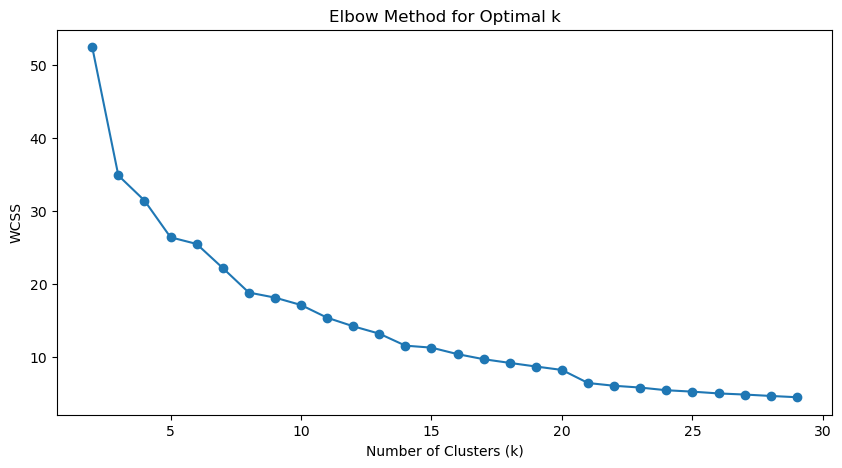

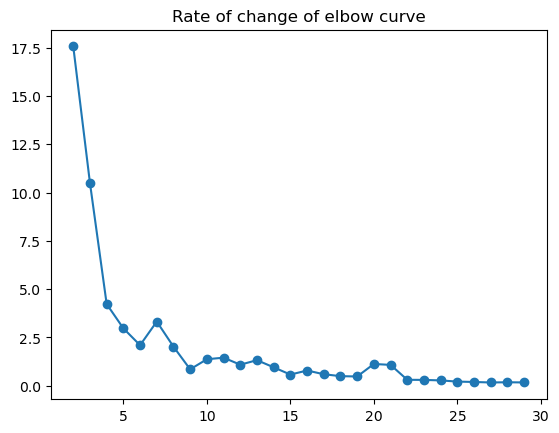

In [18]:
# Find the optimal k using the elbow method
k_range = range(2, 30) # values for the number of clusters `k`
inertia = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(sequence)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()


# plot rate of change of WCSS
rate_of_change = np.gradient(inertia, k_range)
plt.plot(k_range, np.abs(rate_of_change), marker='o')
plt.title('Rate of change of elbow curve')
plt.show()


In [0]:
# Write your reflections here...
# note, elbow method. Fit kmeans model iteratively with increasing k. 
# find within cluster sums of squares across clusters for each iteration. 
# choose where the graph bends, starts to flatten. 

# 1. we use WCSS as we want it as low as possible, without having a too large k
# 2. choose the k where WCSS stops decreasing at a high rate, and starts to flatten. 
# 3. k = 8
# 4. the rate of change of the elbow shows k=6 might be best, as this is last "high" rate of change. 


## Mean-shift Clustering
This exercise is about applying mean-shift clustering to the sequence of poses. 

---
**Task 9 (easy): Fitting the mean-shift algorithm👩‍💻**
1. Run the cell below to:    - create an instance of the `MeanShift()`
 class with a bandwith of 0.629 
    - cluster the pose sequence.




---

In [84]:
# Perform Mean Shift clustering
mean_shift = MeanShift(bandwidth=0.629)
mean_shift.fit(sequence)

,bandwidth,0.629
,seeds,None
,bin_seeding,False
,min_bin_freq,1
,cluster_all,True
,n_jobs,None
,max_iter,300



---
**Task 10 (easy): Visualizing clusters👩‍💻**
1. Extract the cluster labels for each pose in the sequence. Use the `labels_`
 attribute as described in the [documentation on mean-shift clustering.](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MeanShift.html)

2. Visualize the pose sequence, assigning a distinct color to each pose based on its cluster.
3. Extract and plot the cluster centers using the `cluster_centers_`
 attribute.


---

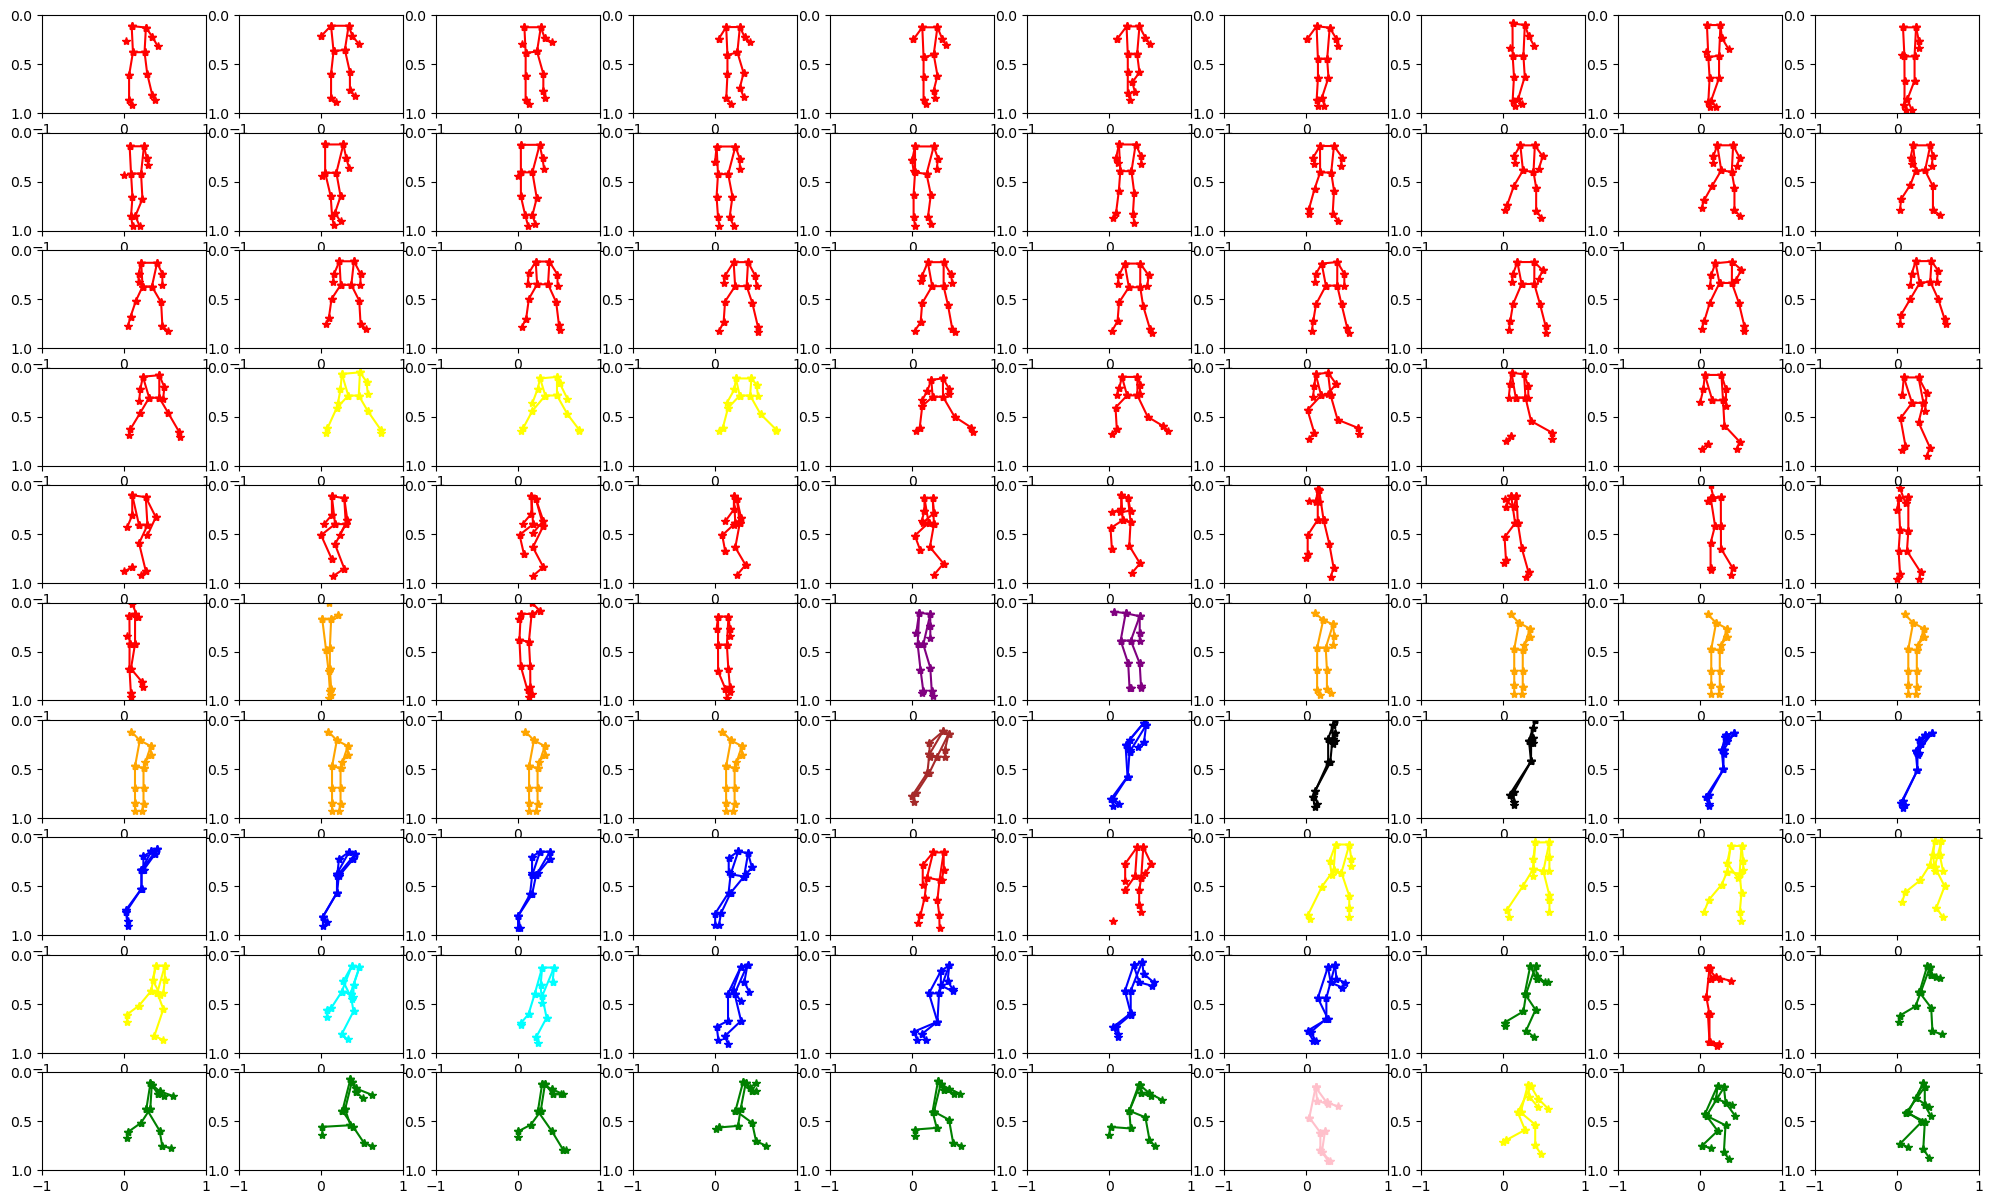

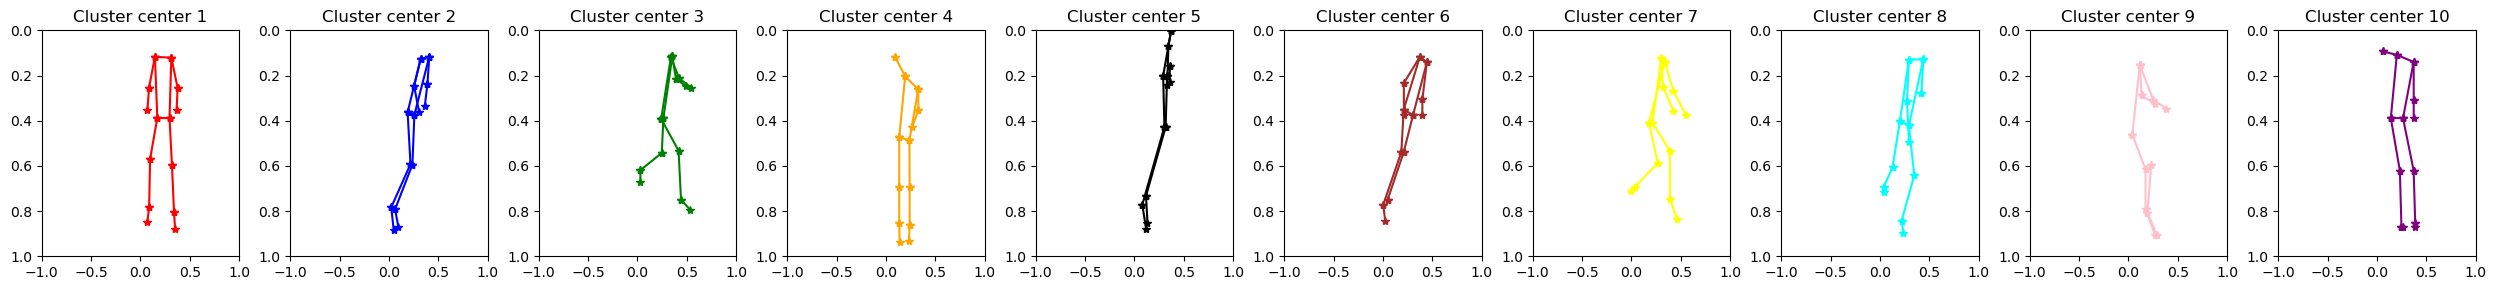

In [86]:
# Write your solution here

cluster_labels = mean_shift.labels_

cluster_centers = mean_shift.cluster_centers_


colors = {0: 'red', 1: 'blue', 2: 'green', 3: "orange", 4: "black", 5: "brown", 6: "yellow", 7: "cyan", 8:"pink", 9:"purple"}  # Map cluster labels to colors
plt.figure(figsize=(25,15))
for i in range(len(sequence)):
    plt.subplot(10, 10, i + 1)
    plot_single_pose(sequence[i], c=colors[cluster_labels[i]], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)
    
plt.show()

plt.figure(figsize=(25, 3))  
for i in range(len(cluster_centers)):
    plt.subplot(1, len(cluster_centers), i+1)
    plt.title(f'Cluster center {i+1}')
    plot_single_pose(cluster_centers[i], c=colors[i], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)

plt.tight_layout()
plt.show()


---
**Task 11 (easy): Reflection and the bandwith parameter👩‍💻💡**
1. Visually examine the plots. What are the characteristics of the poses belonging to each cluster?
2. What is the purpose and what effect of decreasing and increasing the bandwidth parameter to 0.429 and 0.829 have and why?


**Info**
You might encounter longer run times for lower bandwith values.


---

In [0]:
# Write your reflections here...
# green seems to be running to right, spread left. Blue leans to the left but legs are together. 

# bandwidth is how far the point can look. Like size of search window.
# smaller bandwidth gives 11 groups instead of 10. Larger gives 6 clusters. 
# Higher bandwidth, less clusters, because more points can find higher density clusters with high bandwidth. 

## Agglomerative Clustering
This exercise is about applying hierarchical clustering to the poses dataset.

---
**Task 12 (easy): Dendrograms👩‍💻**
1. Run the cell below to generate a dendrogram. 


---

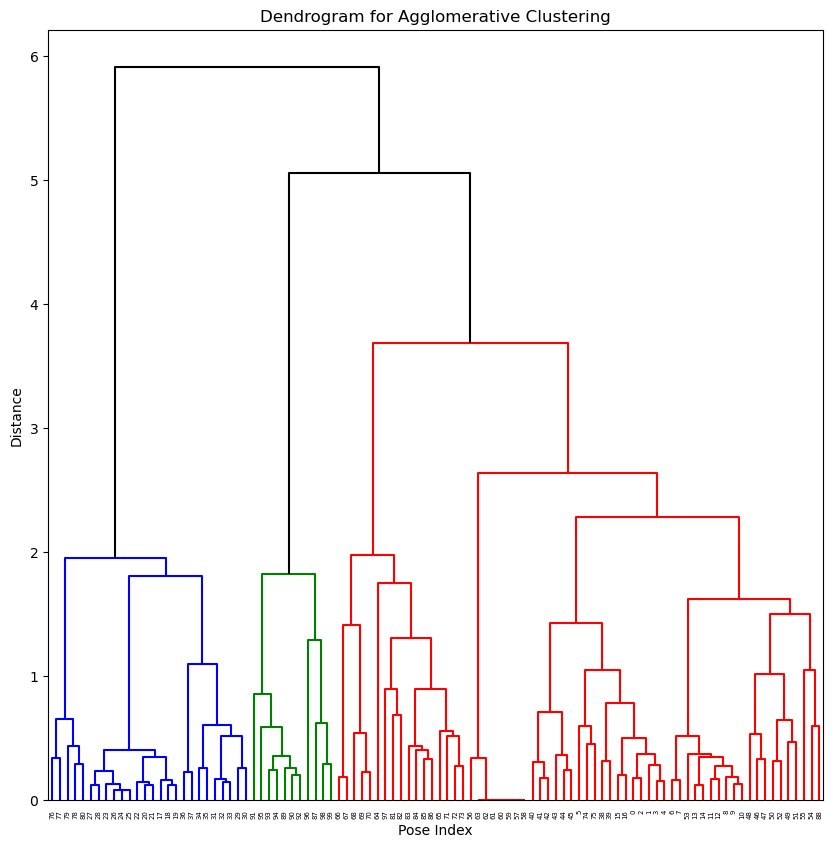

In [54]:
colors = {0: 'black', 1: 'blue', 2: 'green', 3: 'red'}
sns.set_palette([colors[i] for i in range(len(colors))])
shc.set_link_color_palette(None)
plt.figure(figsize=(10,10))
plt.title('Dendrogram for Agglomerative Clustering')
plt.xlabel('Pose Index')
plt.ylabel('Distance')
linkage_matrix = shc.linkage(sequence, method ='ward', metric="euclidean")
Dendrogram = shc.dendrogram(linkage_matrix)


---
**Task 13 (easy): Dendogram💡📽️**
1. How can the number of clusters be determined from the dendrogram?
2. What does the location of a merge node in the dendrogram represent? If two points merge at a very low height, what does it tell about them?
3. Explain what a large differences in node location in the dendogram imply.
4. How many clusters would result from setting the distance threshold to: 0.5, 1.5, 3.0, 4?
5. What types of relationships can agglomerative clustering reveal that non-hierarchical methods might miss?


---

In [0]:
# Write your reflection here...

# 1. find the highest distance that does not overlap with any other clusters. This is around distance=4. 
# there are 3 vertical lines there, so we can choose 3 clusters. 

# 2. the lower the merge point, the lower the distance between the two merged clusters. 

# 3. large difference in node location tells us they have a high distance, and are less likely to belong to the same cluster

# 4. threshold 0.5 would be a lot of clusters
#   1.5 would be 13 clusters
#   3 would be 4 clusters
#   4 would be 3 clusters


---
**Task 14 (easy): Fitting the agglomerative clustering algorithm👩‍💻**
1. Run the cell below creates an instance of the `AgglomerativeClustering()`
 class. The [documentation on agglomerative clustering is given here.](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

2. Select the distance threshold that results in 3 clusters, then apply agglomerative clustering on the sequence. 
3. Extract the cluster labels for each pose in the sequence.
4. Visualize the pose sequence by assigning a distinct color to each pose based on its cluster.


---

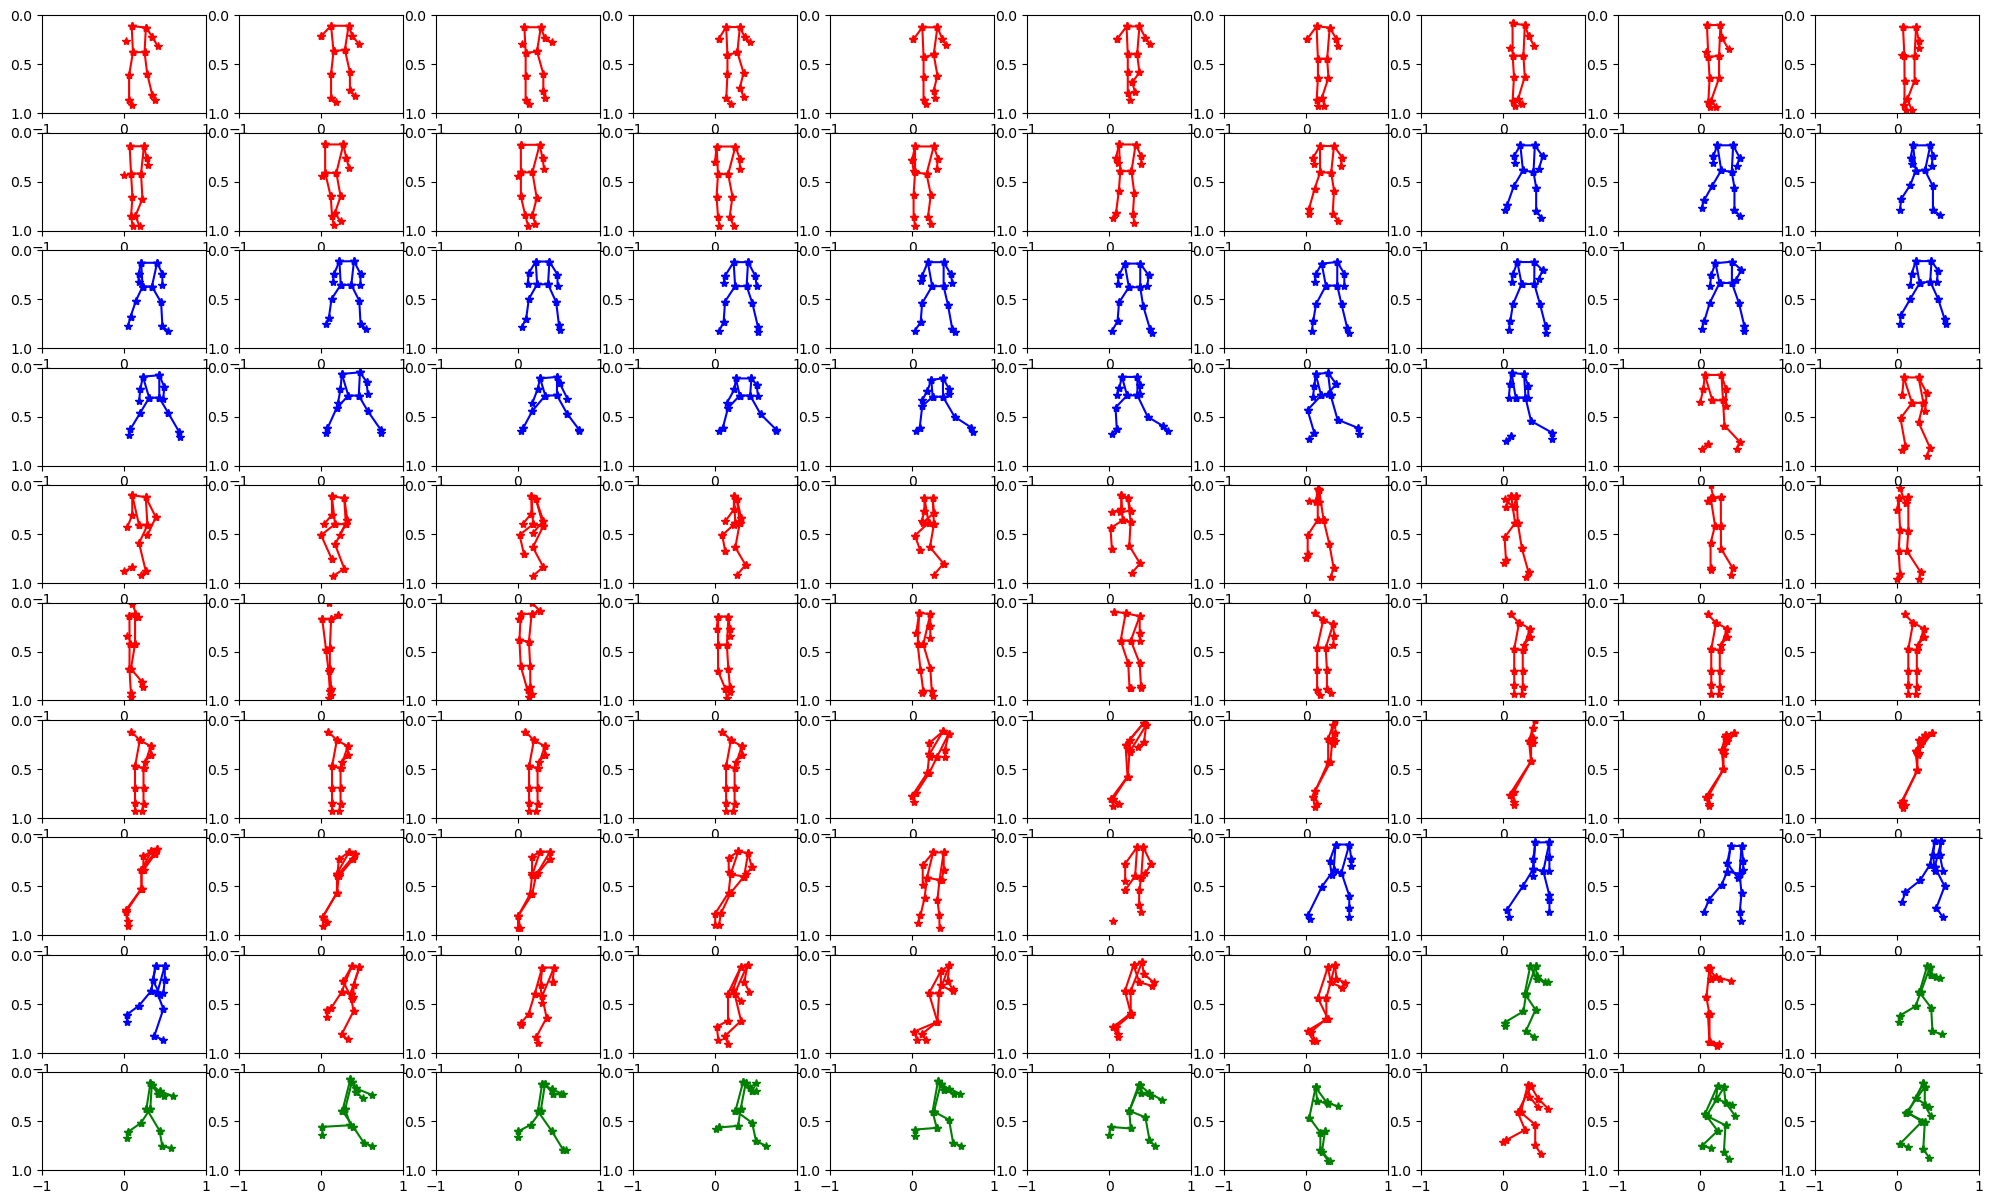

In [87]:
agg_clustering = AgglomerativeClustering(n_clusters=None, metric='euclidean', linkage='ward', distance_threshold=4)

# Write your solution here (agglomerative clustering and cluster centers)

agg_clustering.fit(sequence)

cluster_labels = agg_clustering.labels_

colors = {0: 'red', 1: 'blue', 2: 'green', 3: "orange", 4: "black", 5: "brown", 6: "yellow", 7: "cyan", 8:"pink", 9:"purple"}  # Map cluster labels to colors
plt.figure(figsize=(25,15))
for i in range(len(sequence)):
    plt.subplot(10, 10, i + 1)
    plot_single_pose(sequence[i], c=colors[cluster_labels[i]], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)
    
plt.show()


---
**Task 15 (easy): Agglomerative clustreing algorithm mean pose👩‍💻**
1. The `AgglomerativeClustering()`
 class does not have a method for directly extracting cluster centers. Calculate the mean pose within each cluster for $k = 3$  and plot it.
2. Change the distance metric (try `l1`
 and `cosine`
) and repeat the previous two tasks ([Task 14](#loading11) and [Task 15](#loading12).1). 


---

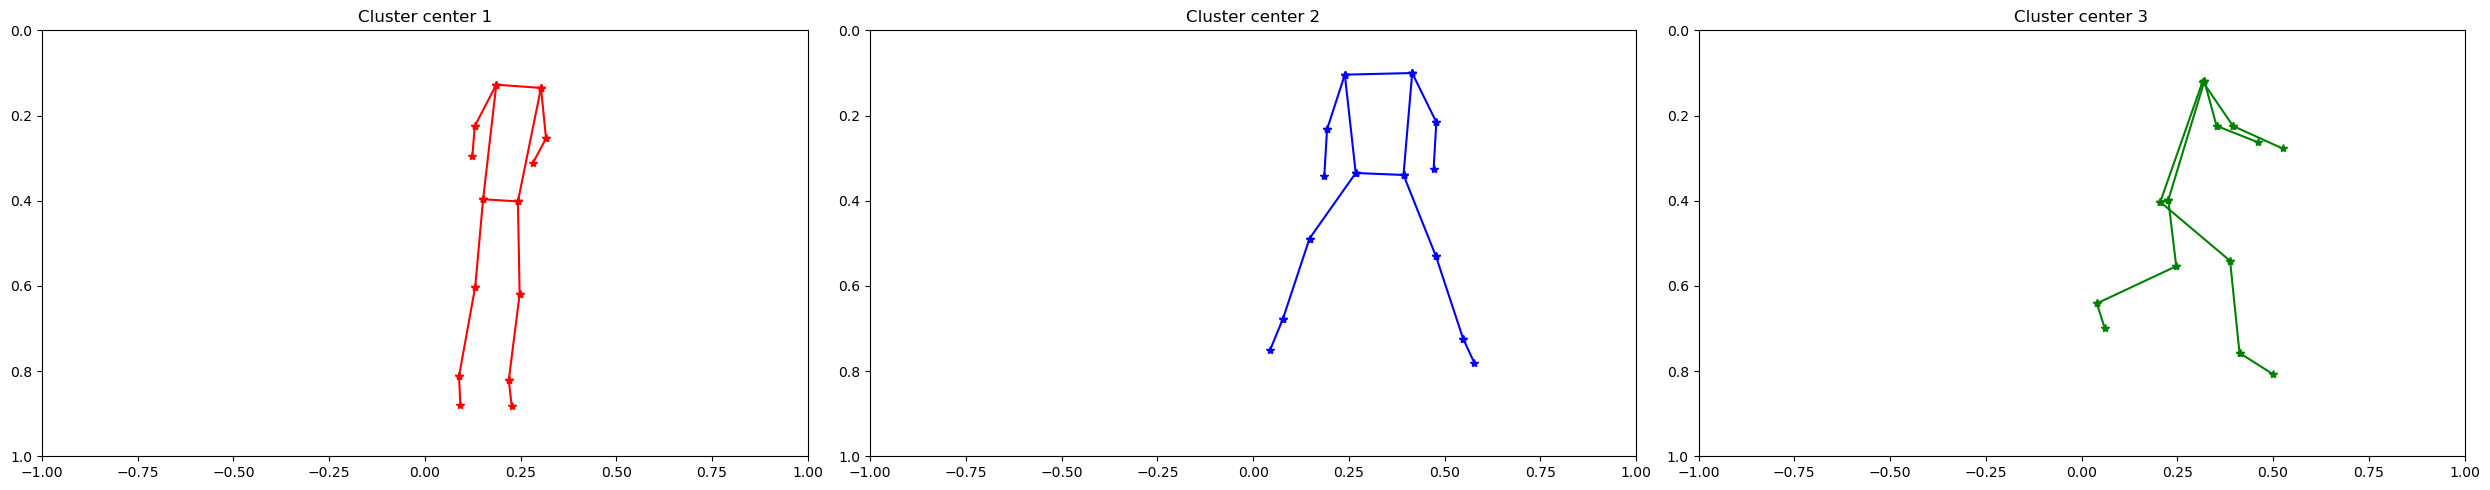

In [88]:
# Write your solution here
mean_cluster_poses = []

for i in range(3):
    indices = np.where(cluster_labels == i)[0]
    cluster_poses = sequence[indices]
    mean_cluster_poses.append(np.mean(cluster_poses, axis=0))

plt.figure(figsize=(25, 5))  
for i in range(len(mean_cluster_poses)):
    plt.subplot(1, len(mean_cluster_poses), i+1)
    plt.title(f'Cluster center {i+1}')
    plot_single_pose(mean_cluster_poses[i], c=colors[i], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)

plt.tight_layout()
plt.show()


---
**Task 16 (easy): Agglomerative clustreing algorithm mean pose💡📽️**
1. What differences do you observe?
2. Explain why these differences occur? 
3. Does a different distance metric result in more meaningful clusters, why/why not?


---

In [0]:
# Write your reflections here...

## Comparison

---
**Task 17 (medium): Compare and reflect on the methods👩‍💻💡📽️**
1. Compare the clustered poses obtained with the different clustering methods (K-means, Mean-shift and Agglomerative clustering). What are the similarities and differences between the pose clusters across methods?
2. Why can clusters look similar across methods? 
3. What are the main reasons behind differences in the clusters?
4. The algorithms use different methods for determining the number of clusters. How do these differences impact the results for the pose data?


---

In [0]:
# Write your relfection here...

#1. usually groups poses with spread legs, legs together, facing front and facing left. 

#2. the methods all use distance as a metric, so poses that are located close will usually be clustered together. 

#3. Difference is how the clusters are found when cluster is more elongated or other shape. 
# k-means is best for distinct, "even" shaped clusters. 
# mean-shift finds density, and uneven shaped clusters will find each other.
# agglomerative also use distance like k-means. Does not use randomness, so will always find same clusters for some threshold. 

# 4. k-means uses the elbow method, where we look at distance from mean within cluster. Here we found 8 clusters to be best fit. But it's still something the user has to decide.
#   mean-shift uses the bandwidth, but finds num of clusters on its own. understanding your data is important. we found between 6 and 11 clusters.
#   agglomerative uses distance threshold that the user has to set. We can use the trick of finding the longest vertical distance, and here it found 3 clusters. Very different from the others. 